# Conditional Value at Risk modelling

In [9]:
import matplotlib.pyplot as plt
import sys 

sys.path.append("../")
sys.path.append("./")

from matplotlib import pyplot as plt
import numpy as np
# from tfds.log import create_logger
# from tfds.plotting import prettify, use_tex

# use_tex()
from scipy import stats
from scipy.integrate import simpson, trapezoid
from tqdm import tqdm

from trading_information.distributions import BetaMixture, Uniform
from trading_information.virtual_values import VirtualValues
from trading_information.mechanism import Mechanism
from trading_information.hyperopt import HyperOpt

%config InlineBackend.figure_format = 'svg'

## 1- Monte Carlo Sampling

99.7095106589151
203.15165723008514


1000it [00:00, 8687.64it/s]

Best alpha 182.18218218218226
CvAR 203.15166278237265
VaR 182.15778117417452


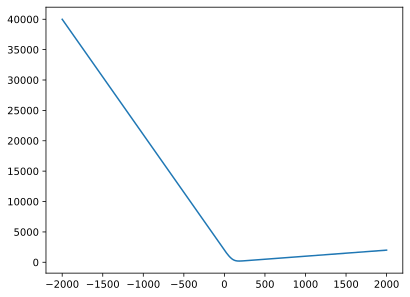

In [10]:
beta = 0.95

sample_size = 100000
losses = np.random.normal(100, 50, size=sample_size)

expected_losses = np.sum(losses, axis=0) / sample_size
print(expected_losses)


def cvar_explicit(losses):
    var = np.quantile(losses, q=beta)
    integral = np.mean(losses[losses>=var])
    return integral 

print(cvar_explicit(losses))

def F(losses, alpha):
    delta = losses - alpha
    delta[delta <= 0] = 0
    return alpha + (1 / (sample_size * (1 - beta))) * np.sum(delta)

alphas = np.linspace(-2000, 2000, 1000)
Fs = np.zeros(len(alphas))
for i, alpha in tqdm(enumerate(alphas)):
    Fs[i] =  F(losses, alpha)


fig, ax = plt.subplots()
ax.plot(alphas, Fs)
best_alpha = alphas[np.argmin(Fs)]
cvar = F(losses, best_alpha)

var = np.quantile(losses, q=beta)

print("Best alpha", best_alpha)
print("CvAR", cvar)
print("VaR", var)


## 2-Portfolio Opt

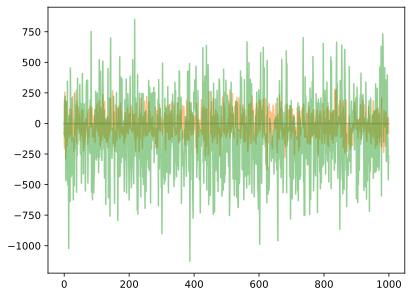

In [11]:
sample_size = 1000

returns = np.random.multivariate_normal([1, 10, 100], [[1, 0, 0], [0, 10000, 0], [0, 0, 100000]], size=sample_size)
losses = -returns

fig, ax = plt.subplots()
ax.plot(losses, alpha=0.5)

In [12]:
beta = 0.95

x = np.array([0, 0, 1])

In [13]:
expected_losses = np.sum(losses, axis=0) / sample_size
print(expected_losses)

[  -1.02009222   -8.31692982 -104.97814341]


In [14]:
def cvar_explicit(x):
    f = losses @ x
    var = np.quantile(f, q=beta)
    integral = np.mean(f[f>=var])
    return integral #/ (1 - beta)

cvar_explicit(x)

var = np.quantile(losses @ x, q=beta)

cvar_explicit(x), var

(535.3878942260533, 407.410187726069)

10000it [00:00, 65057.52it/s]


Best alpha 407.4407440744071
CvAR 535.3878942260532
VaR 407.410187726069


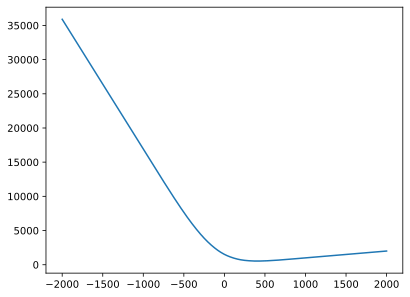

In [15]:
def F(x, alpha):
    delta = losses @ x - alpha
    delta[delta <= 0] = 0
    return alpha + (1 / (sample_size * (1 - beta))) * np.sum(delta)

alphas = np.linspace(-2000, 2000, 10000)
Fs = np.zeros(len(alphas))
for i, alpha in tqdm(enumerate(alphas)):
    Fs[i] =  F(x, alpha)


fig, ax = plt.subplots()
ax.plot(alphas, Fs)
best_alpha = alphas[np.argmin(Fs)]
cvar = F(x, best_alpha)

var = np.quantile(losses @ x, q=beta)

print("Best alpha", best_alpha)
print("CvAR", cvar)
print("VaR", var)

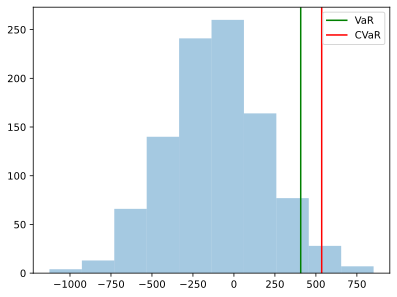

In [16]:
fig, ax = plt.subplots()

ax.hist(losses @ x, alpha=0.4)
ax.axvline(x=var, color="green", label="VaR")
ax.axvline(x=cvar, color="red", label="CVaR")
ax.legend()


In [17]:
import gurobipy as gp
from gurobipy import GRB

model = gp.Model()

alpha = model.addVar(lb=-np.inf, ub=np.inf)
u = model.addMVar(sample_size, lb=0)
x = model.addMVar(3, lb=0, ub=1)

objective = alpha + 1 / (sample_size * (1 - beta)) * gp.quicksum(u)
model.addConstr(gp.quicksum(x) == 1)
model.addConstr(x[2] == 1)

for i in range(sample_size):
    model.addConstr(-losses[i] @ x + alpha + u[i] >= 0)


model.setObjective(objective, GRB.MINIMIZE)
model.optimize()


Set parameter Username
Academic license - for non-commercial use only - expires 2025-05-10
Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (mac64[rosetta2] - Darwin 23.4.0 23E224)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1002 rows, 1004 columns and 5004 nonzeros
Model fingerprint: 0x3e8d154e
Coefficient statistics:
  Matrix range     [2e-03, 1e+03]
  Objective range  [2e-02, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 2 rows and 3 columns
Presolve time: 0.00s
Presolved: 1000 rows, 1001 columns, 2000 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
     149    5.3538789e+02   0.000000e+00   0.000000e+00      0s

Solved in 149 iterations and 0.01 seconds (0.01 work units)
Optimal objective  5.353878942e+02


In [18]:
x.X

array([0., 0., 1.])

In [19]:
model.ObjVal

535.3878942260534

In [20]:
cvar

535.3878942260532

## 3- Trapezoidal Rule

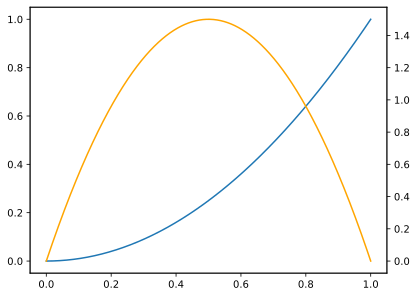

In [22]:
from scipy import stats

xs = np.linspace(0, 1, 1000)
losses = xs ** 2

dist = stats.uniform(0, 1)
dist = stats.beta(2, 2)

pdfs = dist.pdf(xs)

fig, ax = plt.subplots()
ax.plot(xs, losses)
ax2 = ax.twinx()
ax2.plot(xs, pdfs, color="orange")


0.2999994989986988


10000it [00:00, 31610.96it/s]

Best alpha 0.7478747874787479
CvAR 0.8307449010947199
VaR 0.7478747874787479


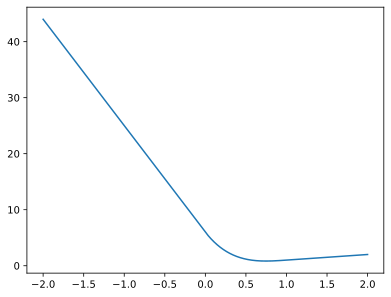

In [57]:
beta = 0.95

expected_losses = trapezoid(y=losses * pdfs, x=xs)
print(expected_losses)


def H(losses, alpha):
    mask = losses <= alpha
    return trapezoid(y=pdfs[mask], x=xs[mask])

def F(losses, alpha):
    delta = np.maximum(0, losses - alpha)
    return alpha + (1 / (1 - beta)) * trapezoid(y=delta * pdfs, x=xs)

alphas = np.linspace(-2, 2, 10000)
Fs = np.zeros(len(alphas))
Hs  = np.zeros(len(alphas))
for i, alpha in tqdm(enumerate(alphas)):
    Fs[i] =  F(losses, alpha)
    Hs[i] = H(losses, alpha)


fig, ax = plt.subplots()
ax.plot(alphas, Fs)
best_alpha = alphas[np.argmin(Fs)]
cvar = F(losses, best_alpha)


print("Best alpha", best_alpha)
print("CvAR", cvar)
print("VaR", best_alpha)


0.7482748274827484


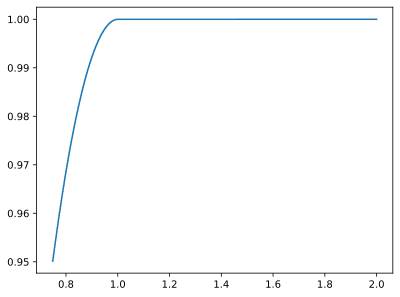

In [58]:
fig, ax = plt.subplots()
mask = Hs >= beta
ax.plot(alphas[mask], Hs[mask])

print(np.min(alphas[mask])) # value at risk!!!

## PO - trapezoid

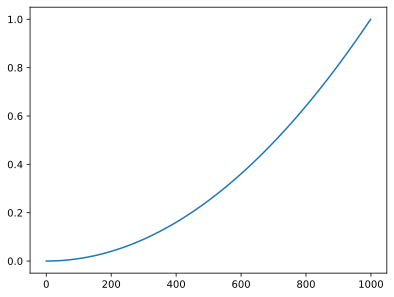

In [59]:
plt.plot(losses)

In [69]:
import gurobipy as gp
from gurobipy import GRB

model = gp.Model()

alpha = model.addVar(lb=-np.inf, ub=np.inf)
u = model.addMVar(sample_size, lb=0)

objective =  alpha + 1 / (sample_size * (1 - beta)) * gp.quicksum(u)

for i in range(sample_size):
    model.addConstr(u[i] >= (losses[i]  - alpha) * pdfs[i])


model.setObjective(objective, GRB.MINIMIZE)
model.optimize()


Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (mac64[rosetta2] - Darwin 23.4.0 23E224)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1000 rows, 1001 columns and 1998 nonzeros
Model fingerprint: 0xc2f17587
Coefficient statistics:
  Matrix range     [6e-03, 1e+00]
  Objective range  [2e-02, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e-09, 6e-01]
Presolve removed 2 rows and 2 columns
Presolve time: 0.00s
Presolved: 998 rows, 999 columns, 1996 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
     320    8.3066168e-01   0.000000e+00   0.000000e+00      0s

Solved in 320 iterations and 0.01 seconds (0.01 work units)
Optimal objective  8.306616826e-01


In [70]:
model.ObjVal

0.8306616825505634

In [71]:
cvar

0.8307449010947199

In [72]:
alpha.X, best_alpha

(0.7479912344777211, 0.7478747874787479)

In [102]:
type = 0.8
threshold_type = 0.75

tau = 1000
beta = 0.99
prob_state0 = 1
tj = prob_state0

alpha = tau * (1 - 2 * prob_state0)

print(alpha)

allocation = 0

externality = 1 - type * (1 + allocation)
if type >= threshold_type:
    externality -= (1 - 2 * type) * allocation
externality *= alpha
externality += tau * prob_state0

externality

-1000


800.0

In [103]:
allocation = 0

ps1 = 1 - tj - tj * allocation + (1 - 2 * type) * np.minimum(0, -allocation)



In [104]:
ps1

0.0

In [ ]:
externality = 1 - self.types[i] * (1 + allocations[i])
                        if type >= threshold_type:
                            externality -= (1 - 2 * self.types[i]) * allocations[i]
                        externality *= alpha